In [ ]:
import os
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.metrics import accuracy_score, classification_report
from skimage.feature import graycomatrix, graycoprops
from scipy.stats import entropy
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay)
import seaborn as sns

In [ ]:
data = []
labels = []
file_name = []
IMG_SIZE = (224, 224)

for sub_folder in os.listdir("Assets/"):
    sub_folder_files = os.listdir(os.path.join("Assets/", sub_folder))
    for i, filename in enumerate(sub_folder_files):
        img_path = os.path.join("Assets/", sub_folder, filename)
        img = cv.imread(img_path)

        # Check if image is loaded successfully
        if img is None:
            print(f"Warning: Could not load image {img_path}. Skipping.")
            continue

        img = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
        img = cv.resize(img, IMG_SIZE) # Resize the image to a consistent size
        img = img.astype(np.uint8)

        data.append(img)
        labels.append(sub_folder)
        name = os.path.splitext(filename)[0]
        file_name.append(filename)

data = np.array(data)
labels = np.array(labels)

In [ ]:
data_augmented = []
labels_augmented = []
paths_augmented = []
file_name_augmented = []
for i in range(len(data)):
    data_augmented.append(data[i])
    labels_augmented.append(labels[i])
    paths_augmented.append(file_name[i]) # Using file_name as a placeholder for path for now
    file_name_augmented.append(file_name[i])

data_augmented = np.array(data_augmented)
labels_augmented = np.array(labels_augmented)

In [ ]:
print("Data sebelum augmentasi: ", len(data))
print("Data setelah augmentasi: ", len(data_augmented))

Data sebelum augmentasi:  1500
Data setelah augmentasi:  1500


In [ ]:
def equalization(image):
    image_equalized = cv.equalizeHist(image)
    return image_equalized

def median_filter(image):
    image_filtered = cv.medianBlur(image, 5)
    return image_filtered

def thresholding(image,threshold):
    tresholded = np.zeros_like(image)
    tresholded[image > threshold] = 255
    tresholded[image <= threshold] = 0
    return tresholded

def opening(image, kernel_size):
    kernel = np.ones(kernel_size,np.uint8)
    opening = cv.morphologyEx(image, cv.MORPH_OPEN, kernel)
    return opening

def closing(image, kernel_size):
    kernel = np.ones(kernel_size,np.uint8)
    closing = cv.morphologyEx(image, cv.MORPH_CLOSE, kernel)
    return closing

In [ ]:
# pada bagian ini bisa gunakan data yang sebelum augmentasi atau setelah augmentasi
dataPreprocessed = []
for i in range(len(data)): # Loop through each image and do preprocessing
    img_equalized = equalization(data[i])
    img_filtered = median_filter(img_equalized)
    img_thresholded = thresholding(img_filtered, 127) # Using 127 as a default threshold value
    img_opened = opening(img_thresholded, (5,5))
    img_closed = closing(img_opened, (5,5))
    dataPreprocessed.append(img_closed)

dataPreprocessed = np.array(dataPreprocessed)

In [ ]:
def glcm(image, derajat):
    if derajat == 0:
        angles = [0]
    elif derajat == 45:
        angles = [np.pi / 4]
    elif derajat == 90:
        angles = [np.pi / 2]
    elif derajat == 135:
        angles = [3 * np.pi / 4]
    else:
        raise ValueError("Invalid angle. It should be one of the following: 0, 45, 90, 135.")

    # mengembalikan matrix glcm dari image
    glcm = graycomatrix(image, [1], angles, 256, symmetric=True, normed=True)
    return glcm

In [ ]:
def correlation(matriks):
	return graycoprops(matriks, 'correlation')[0, 0]

def dissimilarity(matriks):
    return graycoprops(matriks, 'dissimilarity')[0, 0]

def homogenity(matriks):
    return graycoprops(matriks, 'homogeneity')[0, 0]

def contrast(matriks):
    return graycoprops(matriks, 'contrast')[0, 0]

def ASM(matriks):
    return graycoprops(matriks, 'ASM')[0, 0]

def energy(matriks):
    return graycoprops(matriks, 'energy')[0, 0]

def entropyGlcm(matriks):
    return entropy(matriks.ravel())

In [ ]:
Derajat0 = []
Derajat45 = []
Derajat90 = []
Derajat135 = []
for i in range(len(dataPreprocessed)):
    D0 = glcm(dataPreprocessed[i], 0)
    D45 = glcm(dataPreprocessed[i], 45)
    D90 = glcm(dataPreprocessed[i], 90)
    D135 = glcm(dataPreprocessed[i], 135)
    Derajat0.append(D0)
    Derajat45.append(D45)
    Derajat90.append(D90)
    Derajat135.append(D135)

In [ ]:
Kontras0, Kontras45, Kontras90, Kontras135 = [], [], [], []
dissimilarity0, dissimilarity45, dissimilarity90, dissimilarity135 =  [], [], [], []
homogenity0, homogenity45, homogenity90, homogenity135 = [], [], [], []
entropy0, entropy45, entropy90, entropy135 =  [], [], [], []
ASM0, ASM45, ASM90, ASM135 =  [], [], [], []
energy0, energy45, energy90, energy135 =  [], [], [], []
correlation0, correlation45, correlation90, correlation135 = [], [], [], []

In [ ]:
for i in range(len(dataPreprocessed)):
    C0 = correlation(Derajat0[i])
    correlation0.append(C0)
    C45 = correlation(Derajat45[i])
    correlation45.append(C45)
    C90 = correlation(Derajat90[i])
    correlation90.append(C90)
    C135 = correlation(Derajat135[i])
    correlation135.append(C135)

In [ ]:
for i in range(len(data)):
    K0 = contrast(Derajat0[i])
    K45 = contrast(Derajat45[i])
    K90 = contrast(Derajat90[i])
    K135 = contrast(Derajat135[i])
    Kontras0.append(K0)
    Kontras45.append(K45)
    Kontras90.append(K90)
    Kontras135.append(K135)

In [ ]:
for i in range(len(data)):
    Dis0 = dissimilarity(Derajat0[i])
    Dis45 = dissimilarity(Derajat45[i])
    Dis90 = dissimilarity(Derajat90[i])
    Dis135 = dissimilarity(Derajat135[i])
    dissimilarity0.append(Dis0)
    dissimilarity45.append(Dis45)
    dissimilarity90.append(Dis90)
    dissimilarity135.append(Dis135)

In [ ]:
for i in range(len(data)):
    H0 = homogenity(Derajat0[i])
    H45 = homogenity(Derajat45[i])
    H90 = homogenity(Derajat90[i])
    H135 = homogenity(Derajat135[i])
    homogenity0.append(H0)
    homogenity45.append(H45)
    homogenity90.append(H90)
    homogenity135.append(H135)

In [ ]:
for i in range(len(data)):
    E0 = entropyGlcm(Derajat0[i])
    E45 = entropyGlcm(Derajat45[i])
    E90 = entropyGlcm(Derajat90[i])
    E135 = entropyGlcm(Derajat135[i])
    entropy0.append(E0)
    entropy45.append(E45)
    entropy90.append(E90)
    entropy135.append(E135)

In [ ]:
for i in range(len(data)):
    A0 = ASM(Derajat0[i])
    A45 = ASM(Derajat45[i])
    A90 = ASM(Derajat90[i])
    A135 = ASM(Derajat135[i])
    ASM0.append(A0)
    ASM45.append(A45)
    ASM90.append(A90)
    ASM135.append(A135)

In [ ]:
for i in range(len(data)):
    ER0 = energy(Derajat0[i])
    ER45 = energy(Derajat45[i])
    ER90 = energy(Derajat90[i])
    ER135 = energy(Derajat135[i])
    energy0.append(ER0)
    energy45.append(ER45)
    energy90.append(ER90)
    energy135.append(ER135)

In [ ]:
dataTable = {'Filename': file_name, 'Label': labels,
        'Contrast0': Kontras0, 'Contrast45': Kontras45, 'Contrast90': Kontras90, 'Contrast135': Kontras135,
        'Homogeneity0': homogenity0, 'Homogeneity45': homogenity45, 'Homogeneity90': homogenity90, 'Homogeneity135': homogenity135,
        'Dissimilarity0': dissimilarity0, 'Dissimilarity45': dissimilarity45, 'Dissimilarity90': dissimilarity90, 'Dissimilarity135': dissimilarity135,
        'Entropy0': entropy0, 'Entropy45': entropy45, 'Entropy90': entropy90, 'Entropy135': entropy135,
        'ASM0': ASM0, 'ASM45': ASM45, 'ASM90': ASM90, 'ASM135': ASM135,
        'Energy0': energy0, 'Energy45': energy45, 'Energy90': energy90, 'Energy135': energy135,
        'Correlation0': correlation0, 'Correlation45': correlation45, 'Correlation90': correlation90, 'Correlation135': correlation135,
        }
df = pd.DataFrame(dataTable)
df.to_csv('hasil_ekstraksi_1.csv', index=False)

hasilEkstrak = pd.read_csv('hasil_ekstraksi_1.csv')
hasilEkstrak

,Filename,Label,Contrast0,Contrast45,Contrast90,Contrast135,Homogeneity0,Homogeneity45,Homogeneity90,Homogeneity135,...,ASM90,ASM135,Energy0,Energy45,Energy90,Energy135,Correlation0,Correlation45,Correlation90,Correlation135
0,20211129_161527 (Custom).jpg,Die Back,400.938901,321.666432,288.988429,652.485974,0.993834,0.995053,0.995556,0.989966,...,0.495787,0.490253,0.702894,0.703750,0.704122,0.700180,0.987664,0.990103,0.991108,0.979924
1,20211129_163021 (Custom).jpg,Die Back,351.472414,489.037584,399.637152,575.338334,0.994595,0.992479,0.993854,0.991152,...,0.494044,0.491384,0.703412,0.701918,0.702883,0.700988,0.989186,0.984954,0.987704,0.982299
2,20211129_162838 (Custom).jpg,Die Back,341.058416,571.415572,309.816424,380.507853,0.994755,0.991213,0.995235,0.994148,...,0.495343,0.494268,0.703483,0.700981,0.703806,0.703042,0.989508,0.982422,0.990469,0.988295
3,20211129_160927 (Custom).jpg,Die Back,235.616692,498.190694,395.731903,439.349273,0.996377,0.992339,0.993914,0.993243,...,0.493961,0.493294,0.704556,0.701714,0.702824,0.702349,0.992753,0.984677,0.987828,0.986487
4,20211129_163650 (Custom).jpg,Die Back,368.395159,766.246054,715.962324,855.161978,0.994335,0.988216,0.988990,0.986849,...,0.489309,0.487195,0.703234,0.698948,0.699507,0.697993,0.988665,0.976424,0.977970,0.973688
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1495,IMG_20211106_135933 (Custom).jpg,Bacterial Canker,709.453575,1124.524925,583.183857,1022.533130,0.989090,0.982707,0.991032,0.984275,...,0.491335,0.484728,0.699580,0.695134,0.700953,0.696224,0.978170,0.965398,0.982055,0.968537
1496,IMG_20211106_141230 (Custom).jpg,Bacterial Canker,367.093410,749.247421,531.113869,717.865330,0.994355,0.988478,0.991832,0.988960,...,0.491978,0.489154,0.703177,0.699058,0.701411,0.699395,0.988708,0.976952,0.983662,0.977917
1497,IMG_20211106_135734 (Custom).jpg,Bacterial Canker,548.036615,764.938466,527.208620,976.767580,0.991572,0.988236,0.991892,0.984979,...,0.493368,0.486584,0.702191,0.699824,0.702402,0.697555,0.983095,0.976407,0.983739,0.969874
1498,IMG_20211106_142619 (Custom).jpg,Bacterial Canker,653.478339,959.768948,475.138633,914.003398,0.989951,0.985240,0.992693,0.985944,...,0.492777,0.486154,0.700049,0.696757,0.701981,0.697248,0.979900,0.970479,0.985385,0.971887


<Axes: >

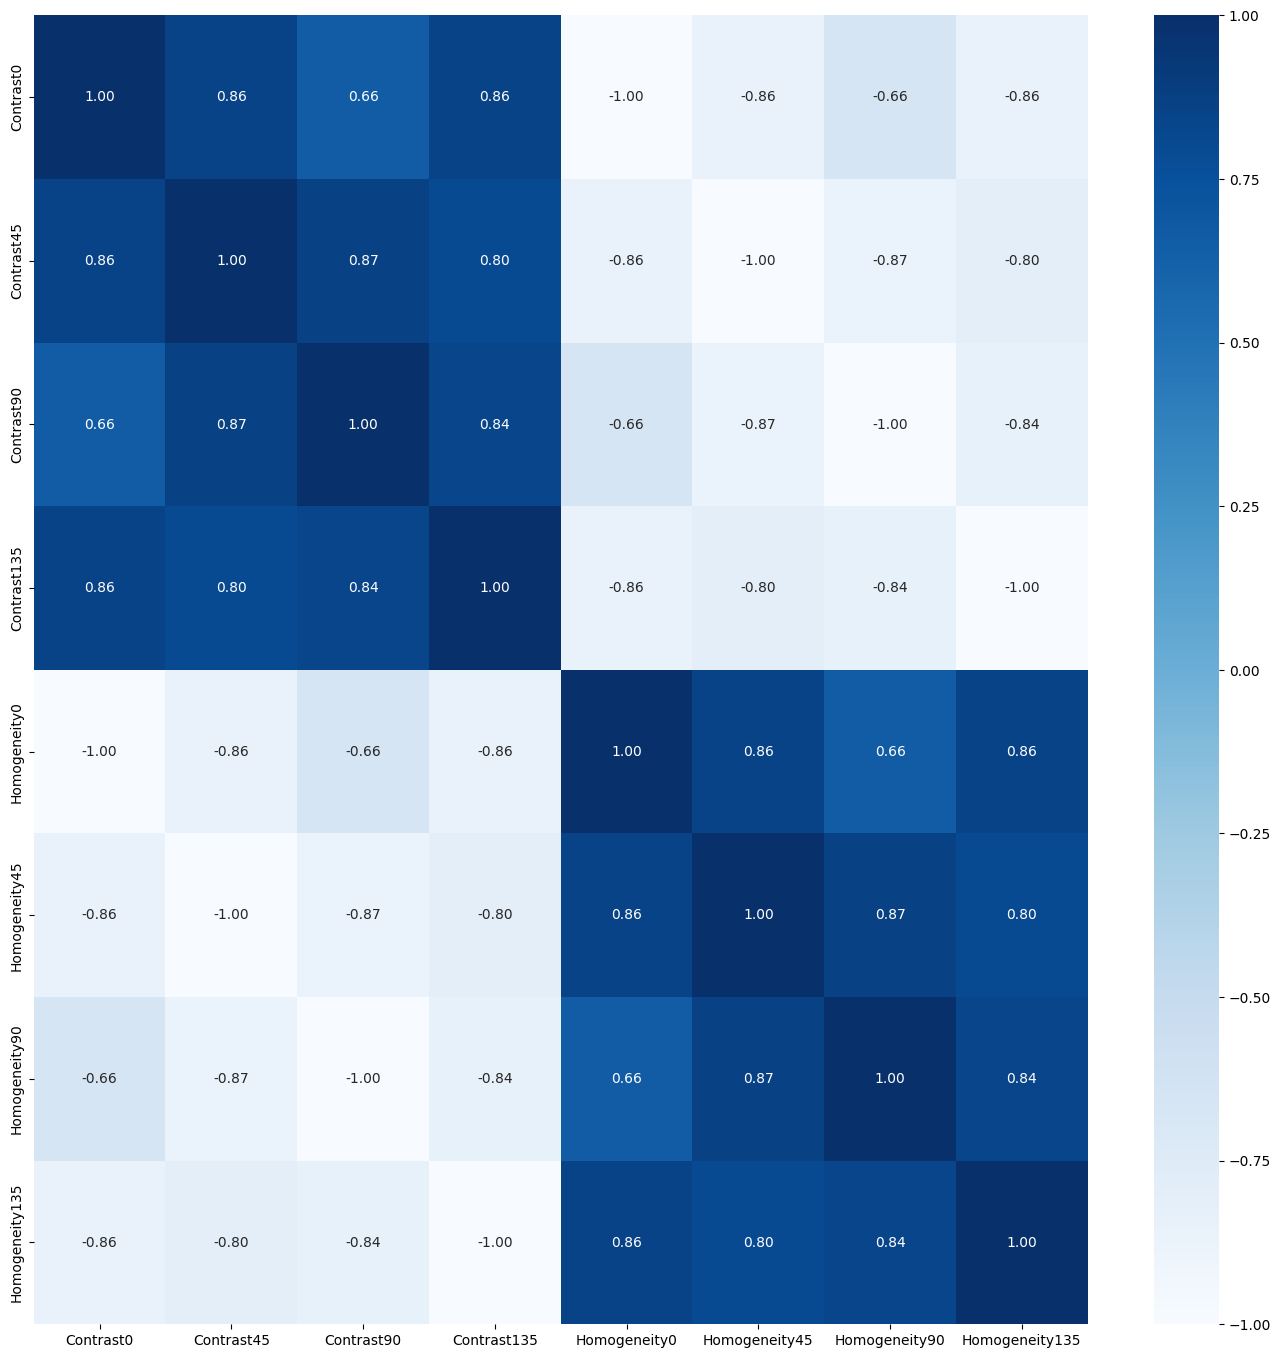

In [ ]:
# Menghitung korelasi
correlation = hasilEkstrak.drop(columns=['Label','Filename']).corr()

# Menyaring fitur yang memiliki korelasi absolut lebih dari 0.95 dengan label
threshold = 0.95 # atur threshold ini untuk menentukan seberapa besar korelasi yang ingin disaring
selectionFeature = []
columns = np.full((correlation.shape[0],), True, dtype=bool)
for i in range(correlation.shape[0]):
	for j in range(i+1, correlation.shape[0]):
		if correlation.iloc[i,j] >= threshold:
			if columns[j]:
				columns[j] = False
select = hasilEkstrak.drop(columns=['Label','Filename']).columns[columns]
x_new = hasilEkstrak[select]
x_new
y = hasilEkstrak['Label']
plt.figure(figsize=(17,17))
sns.heatmap(x_new.corr(), annot=True, cmap='Blues', fmt=".2f")

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(x_new, y, test_size=0.2, random_state=42)
print(X_train.shape)
print(X_test.shape)

(1200, 8)
(300, 8)


In [ ]:
X_test = (X_test - X_train.mean()) / X_train.std()
X_train = (X_train - X_train.mean()) / X_train.std()

In [ ]:
def generateClassificationReport(y_true, y_pred):
	print(classification_report(y_true, y_pred))
	print(confusion_matrix(y_true, y_pred))
	print('Accuracy:', accuracy_score(y_true, y_pred))

# Define classifiers
rf = RandomForestClassifier(n_estimators=5, random_state=42)
svm = SVC(kernel='rbf', random_state=42)
knn = KNeighborsClassifier(n_neighbors=5)

In [ ]:
# Train Random Forest Classifier
rf.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("------Training Set------")
y_pred = rf.predict(X_train)
generateClassificationReport( y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = rf.predict(X_test)
generateClassificationReport( y_test, y_pred)

------Training Set------
                  precision    recall  f1-score   support

Bacterial Canker       0.96      0.98      0.97       390
        Die Back       0.96      0.95      0.96       396
     Sooty Mould       0.96      0.95      0.95       414

        accuracy                           0.96      1200
       macro avg       0.96      0.96      0.96      1200
    weighted avg       0.96      0.96      0.96      1200

[[381   2   7]
 [  8 377  11]
 [  8  13 393]]
Accuracy: 0.9591666666666666

------Testing Set------
                  precision    recall  f1-score   support

Bacterial Canker       0.68      0.72      0.70       110
        Die Back       0.70      0.68      0.69       104
     Sooty Mould       0.57      0.55      0.56        86

        accuracy                           0.66       300
       macro avg       0.65      0.65      0.65       300
    weighted avg       0.66      0.66      0.66       300

[[79 14 17]
 [15 71 18]
 [22 17 47]]
Accuracy: 0.65666666

In [ ]:
# Train SVM Classifier
svm.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("\n------Training Set------")
y_pred = svm.predict(X_train)
generateClassificationReport( y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = svm.predict(X_test)
generateClassificationReport( y_test, y_pred)


------Training Set------
                  precision    recall  f1-score   support

Bacterial Canker       0.78      0.84      0.81       390
        Die Back       0.69      0.69      0.69       396
     Sooty Mould       0.65      0.60      0.63       414

        accuracy                           0.71      1200
       macro avg       0.71      0.71      0.71      1200
    weighted avg       0.71      0.71      0.71      1200

[[328  30  32]
 [ 20 273 103]
 [ 73  91 250]]
Accuracy: 0.7091666666666666

------Testing Set------
                  precision    recall  f1-score   support

Bacterial Canker       0.72      0.76      0.74       110
        Die Back       0.71      0.59      0.64       104
     Sooty Mould       0.51      0.58      0.54        86

        accuracy                           0.65       300
       macro avg       0.65      0.64      0.64       300
    weighted avg       0.66      0.65      0.65       300

[[84 13 13]
 [ 8 61 35]
 [24 12 50]]
Accuracy: 0.65


In [ ]:
# Train KNN Classifier
knn.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("\n------Training Set------")
y_pred = knn.predict(X_train)
generateClassificationReport( y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = knn.predict(X_test)
generateClassificationReport( y_test, y_pred)


------Training Set------
                  precision    recall  f1-score   support

Bacterial Canker       0.75      0.89      0.81       390
        Die Back       0.76      0.78      0.77       396
     Sooty Mould       0.76      0.61      0.68       414

        accuracy                           0.76      1200
       macro avg       0.76      0.76      0.75      1200
    weighted avg       0.76      0.76      0.75      1200

[[346  20  24]
 [ 31 308  57]
 [ 85  76 253]]
Accuracy: 0.7558333333333334

------Testing Set------
                  precision    recall  f1-score   support

Bacterial Canker       0.70      0.78      0.74       110
        Die Back       0.69      0.71      0.70       104
     Sooty Mould       0.55      0.45      0.50        86

        accuracy                           0.66       300
       macro avg       0.65      0.65      0.65       300
    weighted avg       0.66      0.66      0.66       300

[[86 11 13]
 [11 74 19]
 [25 22 39]]
Accuracy: 0.6633333

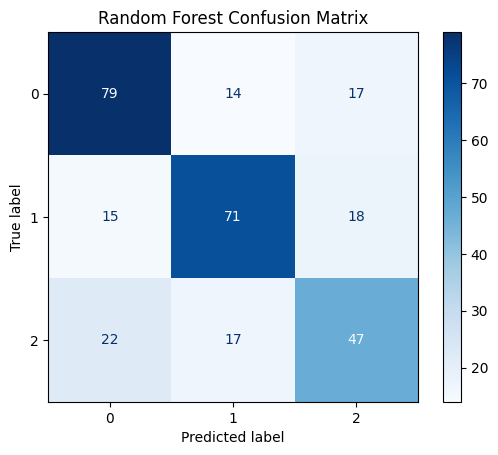

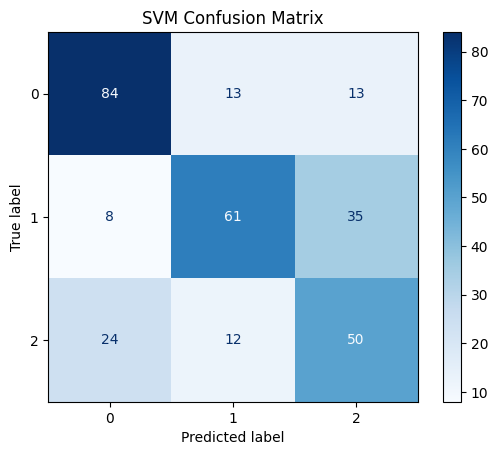

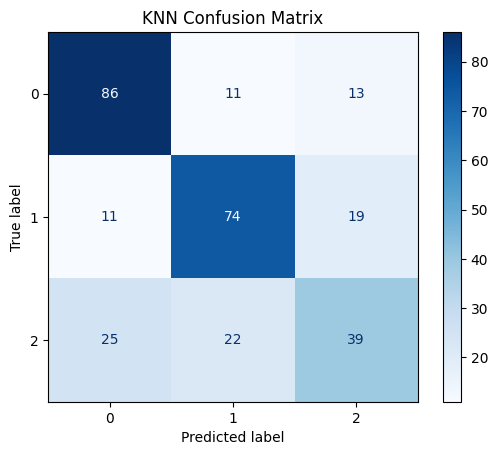

In [ ]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(title)
    plt.show()

# Plot confusion matrix for Random Forest
plot_confusion_matrix(y_test, rf.predict(X_test), "Random Forest Confusion Matrix")
# Plot confusion matrix for SVM
plot_confusion_matrix(y_test, svm.predict(X_test), "SVM Confusion Matrix")
# Plot confusion matrix for KNN
plot_confusion_matrix(y_test, knn.predict(X_test), "KNN Confusion Matrix")